In [8]:
#!/usr/bin/env python3

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

import torch
from torch.utils.data import Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [10]:
DATASET = "Tobi-Bueck/customer-support-tickets"
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

In [11]:
def read_idx(path):
    return np.loadtxt(path, dtype=np.int64)


def split_df(df, root):

    train_idx = read_idx(root / "data/train_idx.txt")
    val_idx = read_idx(root / "data/val_idx.txt")
    test_idx = read_idx(root / "data/test_idx.txt")

    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy()
    }


In [12]:
def perform_eda(splits):

    print("\n" + "="*80)
    print("EDA")
    print("="*80)

    # split sizes
    print("\nSplit sizes:")
    for k,v in splits.items():
        print(k,len(v))

    # missing values
    print("\nMissing values:")
    for k,v in splits.items():
        print(
            k,
            "subject:",v.subject.isna().mean(),
            "body:",v.body.isna().mean()
        )

    # language distribution
    print("\nLanguages:")
    for k,v in splits.items():
        print(k)
        print(v.language.value_counts(normalize=True))

    # queue distribution

    train = splits["train"]

    plt.figure(figsize=(12,6))

    q = train.queue.value_counts().head(15)

    sns.barplot(
        x=q.values,
        y=q.index,
        color="steelblue"
    )

    plt.title("Top 15 queue classes")
    plt.show()

    # imbalance

    print("\nQueue statistics")

    print("num classes:",len(q))
    print("max:",q.max())
    print("min:",q.min())
    print("median:",q.median())
    print("imbalance:",q.max()/q.min())

    # priority

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=train,
        x="priority",
        order=["very_low","low","medium","high","critical"]
    )

    plt.title("Priority distribution")
    plt.show()

    # type

    plt.figure(figsize=(6,6))

    train.type.value_counts().plot(
        kind="pie",
        autopct="%1.1f%%"
    )

    plt.title("Type distribution")
    plt.show()

    # text length

    lengths = []

    for k,v in splits.items():

        text = v.subject.fillna("") + " " + v.body.fillna("")
        lens = text.str.split().str.len()

        lengths.extend(lens)

        plt.hist(
            lens,
            bins=40,
            alpha=.5,
            label=k
        )

        print(
            k,
            "median:",lens.median(),
            "p95:",lens.quantile(.95),
            "max:",lens.max()
        )

    plt.legend()
    plt.title("Text lengths")
    plt.show()

    max_len = int(np.percentile(lengths,95))

    return {
        "max_length":min(max_len,256),
        "num_queue":train.queue.nunique(),
        "num_priority":train.priority.nunique(),
        "num_type":train.type.nunique()
    }

In [13]:

def run_teacher_baseline(splits):

    print("\n" + "="*80)
    print("BASELINE")
    print("="*80)

    def make_text(df):
        return (
            df.subject.fillna("") +
            " " +
            df.body.fillna("")
        ).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    vectorizer = TfidfVectorizer(
        max_features=100000,
        ngram_range=(1,2),
        min_df=2
    )

    Xtr = vectorizer.fit_transform(X_train)
    Xte = vectorizer.transform(X_test)

    results = {}

    for target in ["queue","priority","type"]:

        print("\nTraining",target)

        ytr = splits["train"][target].astype(str)
        yte = splits["test"][target].astype(str)

        clf = LinearSVC()

        clf.fit(Xtr,ytr)

        pred = clf.predict(Xte)

        acc = accuracy_score(yte,pred)

        if target == "queue":

            mf1 = f1_score(yte,pred,average="macro")

            results["queue_mf1"] = mf1
            results["queue_acc"] = acc

            print("MacroF1:",mf1)

        else:

            results[f"{target}_acc"] = acc

        print("Accuracy:",acc)

    score = (
        0.7*results["queue_mf1"] +
        0.15*results["priority_acc"] +
        0.15*results["type_acc"]
    )

    results["score"] = score

    print("\Baseline score:",score)

    return results


In [14]:

def run_improved_baseline(splits):

    print("\n" + "="*80)
    print("IMPROVED TFIDF")
    print("="*80)

    def make_text(df):
        return (
            df.subject.fillna("") +
            " " +
            df.body.fillna("")
        ).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    word_vec = TfidfVectorizer(
        max_features=200000,
        ngram_range=(1,3),
        min_df=2,
        sublinear_tf=True
    )

    char_vec = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        max_features=100000
    )

    Xtr_word = word_vec.fit_transform(X_train)
    Xte_word = word_vec.transform(X_test)

    Xtr_char = char_vec.fit_transform(X_train)
    Xte_char = char_vec.transform(X_test)

    Xtr = hstack([Xtr_word,Xtr_char])
    Xte = hstack([Xte_word,Xte_char])

    results = {}

    for target in ["queue","priority","type"]:

        print("\nTraining",target)

        ytr = splits["train"][target].astype(str)
        yte = splits["test"][target].astype(str)

        clf = LinearSVC(class_weight="balanced")

        clf.fit(Xtr,ytr)

        pred = clf.predict(Xte)

        acc = accuracy_score(yte,pred)

        if target == "queue":

            mf1 = f1_score(yte,pred,average="macro")

            results["queue_mf1"] = mf1
            results["queue_acc"] = acc

            print("MacroF1:",mf1)

        else:

            results[f"{target}_acc"] = acc

        print("Accuracy:",acc)

    score = (
        0.7*results["queue_mf1"] +
        0.15*results["priority_acc"] +
        0.15*results["type_acc"]
    )

    results["score"] = score

    print("\nImproved score:",score)

    return results


In [15]:

def confidence_analysis(model, Xte, y_true):

    decision = model.decision_function(Xte)
    confidence = decision.max(axis=1)

    pred = model.predict(Xte)

    df = pd.DataFrame({
        "y_true":y_true,
        "y_pred":pred,
        "conf":confidence
    })

    df = df.sort_values("conf",ascending=False)

    coverages = np.linspace(.5,1.0,10)

    scores = []

    for c in coverages:

        n = int(len(df)*c)

        subset = df.iloc[:n]

        f1 = f1_score(
            subset.y_true,
            subset.y_pred,
            average="macro"
        )

        scores.append(f1)

        print(c,f1)

    plt.plot(coverages,scores,marker="o")
    plt.xlabel("coverage")
    plt.ylabel("macroF1")
    plt.title("confidence analysis")
    plt.show()



In [16]:

def compare_models(baseline, improved):

    print("\nMODEL COMPARISON")

    df = pd.DataFrame({

        "Model":[
            "Baseline",
            "Improved TFIDF"
        ],

        "MacroF1(queue)":[
            baseline["queue_mf1"],
            improved["queue_mf1"]
        ],

        "Acc(queue)":[
            baseline["queue_acc"],
            improved["queue_acc"]
        ],

        "Acc(priority)":[
            baseline["priority_acc"],
            improved["priority_acc"]
        ],

        "Acc(type)":[
            baseline["type_acc"],
            improved["type_acc"]
        ],

        "Score":[
            baseline["score"],
            improved["score"]
        ]

    })

    print(df)

    df.plot(
        x="Model",
        y="Score",
        kind="bar",
        legend=False
    )

    plt.title("Model comparison")
    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():

    root = Path(".")

    print("Loading dataset...")

    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()

    splits = split_df(df,root)

    for k in splits:
        splits[k]["type"] = splits[k]["type"].fillna("Unknown")

    # EDA
    eda_info = perform_eda(splits)

    # baseline
    baseline_results = run_teacher_baseline(splits)

    # improved
    improved_results = run_improved_baseline(splits)

    # comparison
    compare_models(
        baseline_results,
        improved_results
    )

Loading dataset...

EDA

Split sizes:
train 49412
val 6176
test 6177

Missing values:
train subject: 0.08637577916295637 body: 4.0475997733344126e-05
val subject: 0.0817681347150259 body: 0.0
test subject: 0.0851546057956937 body: 0.0

Languages:
train
language
de    0.542358
en    0.457642
Name: proportion, dtype: float64
val
language
de    0.54647
en    0.45353
Name: proportion, dtype: float64
test
language
de    0.539097
en    0.460903
Name: proportion, dtype: float64


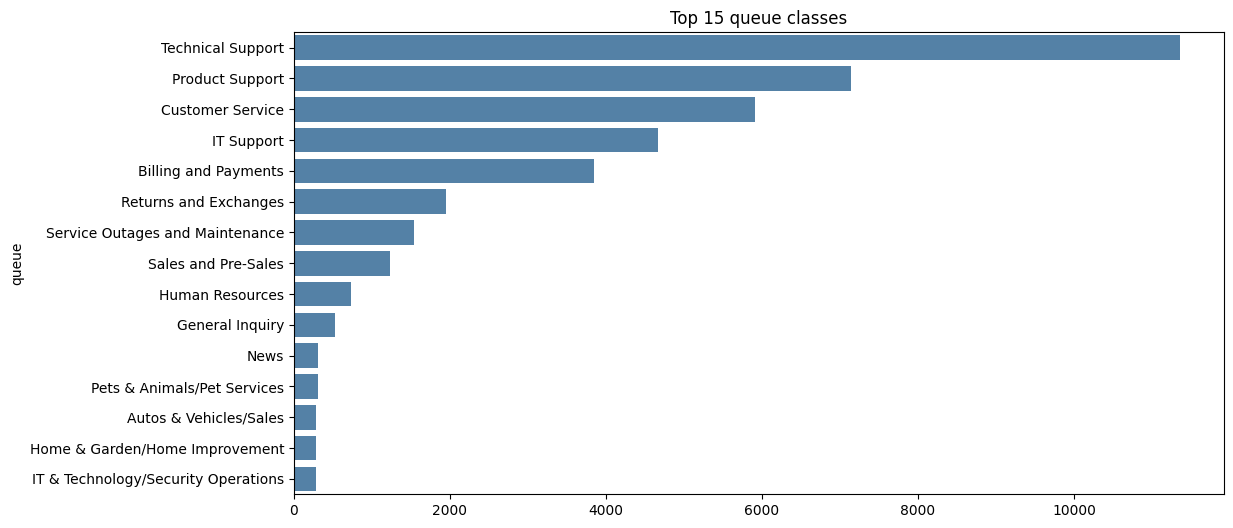


Queue statistics
num classes: 15
max: 11354
min: 285
median: 1228.0
imbalance: 39.83859649122807


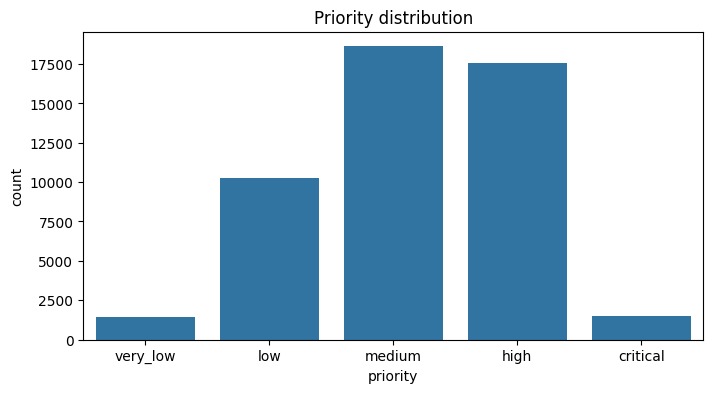

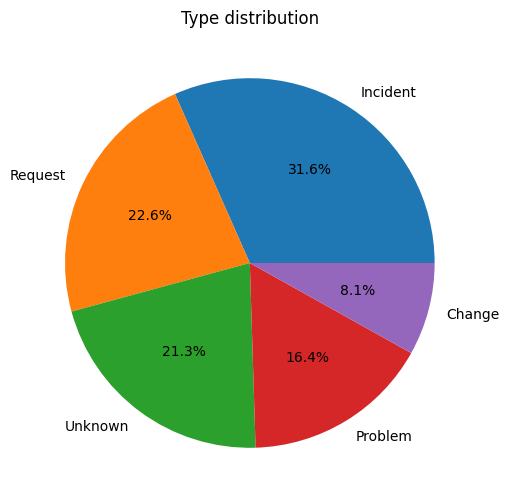

train median: 62.0 p95: 108.0 max: 283
val median: 62.0 p95: 108.0 max: 235
test median: 62.0 p95: 108.0 max: 221


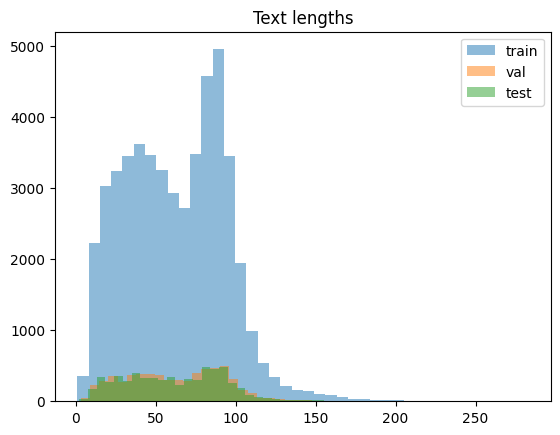


BASELINE

Training queue
MacroF1: 0.889771950208777
Accuracy: 0.6822081916788085

Training priority
Accuracy: 0.6920835356969403

Training type
Accuracy: 0.8934757973126113
\Baseline score: 0.8606742650975766

IMPROVED TFIDF

Training queue
MacroF1: 0.9011280046852232
Accuracy: 0.6789703739679456

Training priority
Accuracy: 0.7089201877934272

Training type
Accuracy: 0.8993038691921644

Improved score: 0.872023211827495

MODEL COMPARISON
            Model  MacroF1(queue)  Acc(queue)  Acc(priority)  Acc(type)  \
0        Baseline        0.889772    0.682208       0.692084   0.893476   
1  Improved TFIDF        0.901128    0.678970       0.708920   0.899304   

      Score  
0  0.860674  
1  0.872023  


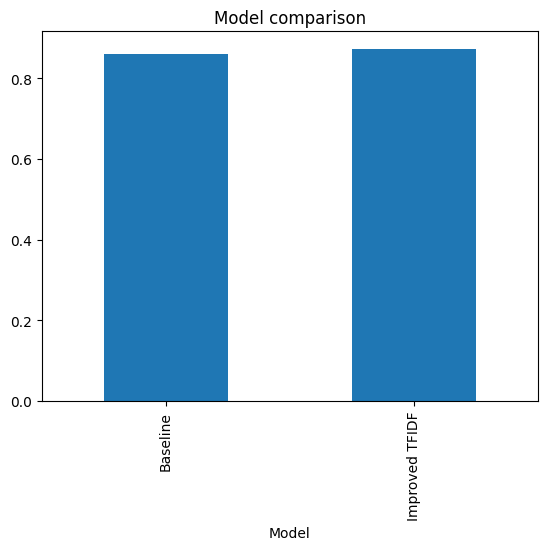

In [17]:
if __name__ == "__main__":
    main()